In [1]:
# akses file data yang ada di Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# import semua pustaka yang dibutuhkan
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [3]:
# Load file CSV dari folder Drive dan membaca file CSV dari Google Drive
df = pd.read_csv('/content/drive/MyDrive/MY SEMEST8R/DATA VALID/HASIL DATA PER DESA.csv')

In [4]:
# Mengecek apakah struktur data sudah benar dan melihat nama kolom dan beberapa nilai awal data
print(df.head())

   Tahun  Bulan   RUTE-DESA  KONSUMSI
0   2022      1  RUTE: A101     12752
1   2022      1  RUTE: A102     14542
2   2022      1  RUTE: A103      4310
3   2022      1  RUTE: A104     20587
4   2022      1  RUTE: A105      4646


In [5]:
# Memastikan nama kolom di dataset
print(df.columns)

Index(['Tahun', 'Bulan', 'RUTE-DESA', 'KONSUMSI'], dtype='object')


In [6]:
# df.copy() — amanin supaya operasi selanjutnya tidak merubah df asli secara tidak sengaja
# astype(str) — ubah kolom Tahun dan Bulan jadi string
# str.zfill(2) — pastikan Bulan seperti 1 jadi 01, biar format tanggal valid
# '01' — karena datanya bulanan, kita set selalu ke tanggal 1 tiap bulannya
# pd.to_datetime(...) — ubah string jadi objek tanggal datetime64
# print(df.dtypes) — ngecek apakah Tanggal udah jadi datetime, bagus banget

df = df.copy()
df['Tanggal'] = pd.to_datetime(df['Tahun'].astype(str) + '-' + df['Bulan'].astype(str).str.zfill(2) + '-01')

# Cek hasilnya
print(df[['Tahun', 'Bulan', 'Tanggal']].head())

# Cek tipe data tiap kolom
print(df.dtypes)

   Tahun  Bulan    Tanggal
0   2022      1 2022-01-01
1   2022      1 2022-01-01
2   2022      1 2022-01-01
3   2022      1 2022-01-01
4   2022      1 2022-01-01
Tahun                 int64
Bulan                 int64
RUTE-DESA            object
KONSUMSI              int64
Tanggal      datetime64[ns]
dtype: object


In [7]:
# Menjadikan kolom Tanggal sebagai indeks time series
# Langkah: Set 'Tanggal' sebagai index

df = df.set_index('Tanggal')
df = df.sort_index()

In [26]:
# Memfilter data berdasarkan RUTE, dalam hal ini RUTE: RSUD
# Menyimpan hasilnya di df_rute agar bisa fokus analisis hanya untuk rute itu

df_rute = df[df['RUTE-DESA'] == 'RUTE: RSUD'].copy()
print(df_rute.head())
print(f"Jumlah data rute RSUD: {len(df_rute)}")

            Tahun  Bulan   RUTE-DESA  KONSUMSI
Tanggal                                       
2024-06-01   2024      6  RUTE: RSUD     13736
2024-07-01   2024      7  RUTE: RSUD     12878
2024-08-01   2024      8  RUTE: RSUD      7886
2024-09-01   2024      9  RUTE: RSUD     11855
2024-10-01   2024     10  RUTE: RSUD     12024
Jumlah data rute RSUD: 7


In [27]:
df_rute = df_rute.sort_index()

In [28]:
series_rsud = df_rute['KONSUMSI']
print(series_rsud.index)

DatetimeIndex(['2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01',
               '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='Tanggal', freq=None)


In [29]:
# Hitung rata-rata konsumsi dari data yang ada
mean_konsumsi = series_rsud.mean()

print(f"Rata-rata konsumsi air: {mean_konsumsi:.2f} m³")

Rata-rata konsumsi air: 11846.43 m³


In [30]:
# Prediksi untuk 1 bulan ke depan pakai rata-rata
next_month = pd.to_datetime(series_rsud.index[-1]) + pd.DateOffset(months=1)

forecast_simple = pd.Series([mean_konsumsi], index=[next_month])
print(forecast_simple)

2025-01-01    11846.428571
dtype: float64


In [31]:
n_forecast = 3  # jumlah bulan yang ingin diprediksi

# Buat index untuk 3 bulan ke depan
last_date = pd.to_datetime(series_rsud.index[-1])
future_dates = [last_date + pd.DateOffset(months=i) for i in range(1, n_forecast+1)]

# Forecast: semua bulan pakai nilai rata-rata
forecast_simple_multi = pd.Series([mean_konsumsi]*n_forecast, index=future_dates)
print(forecast_simple_multi)

2025-01-01    11846.428571
2025-02-01    11846.428571
2025-03-01    11846.428571
dtype: float64


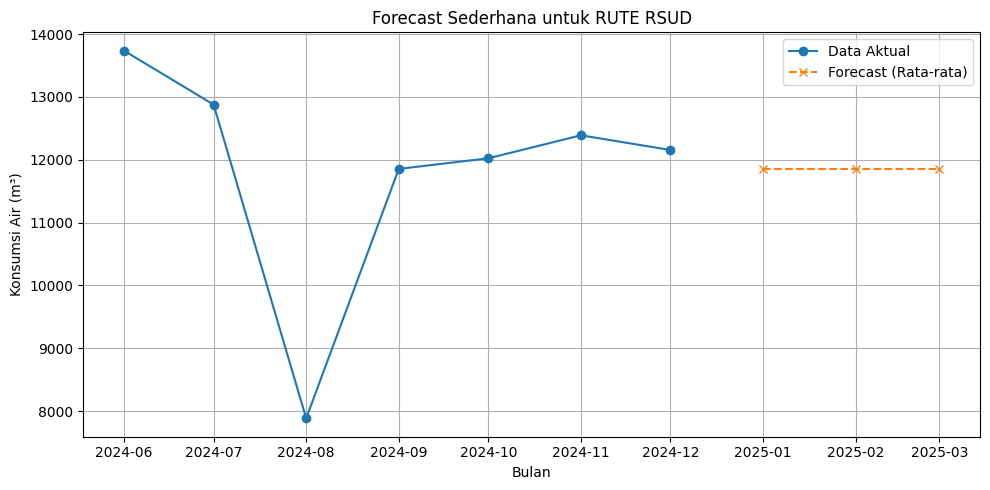

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(series_rsud, label='Data Aktual', marker='o')
plt.plot(forecast_simple_multi, label='Forecast (Rata-rata)', linestyle='--', marker='x')
plt.title('Forecast Sederhana untuk RUTE RSUD')
plt.xlabel('Bulan')
plt.ylabel('Konsumsi Air (m³)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
import pandas as pd

# Simpan ke file .pkl
forecast_simple_multi.to_pickle('forecast_rsud_simple.pkl')

from google.colab import files
files.download('forecast_rsud_simple.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>